The aim of this notebook is to compare NBr54 against 52. In 54 qrun is much smaller for no apparent reason.

For this reason, I'll compare the MSW input files for both runs.

The outcom from the comparrison is recorded in ./MSW_In_NBr54_Vs_NBr52.xlsx

# 0. Basics

## 0.0 Imports

In [1]:
import os
import pandas as pd
import shutil as sh

In [2]:
import yaml

In [3]:
from WS_Mdl.core import *
from WS_Mdl.imod.msw import para_sim, read as r_MSW_In

## 0.1 Options

In [4]:
M = Mdl_N('NBr54')
MB = Mdl_N('NBr52')

# 1. Load MSW Ins as DFs

In [5]:
d_DF = {M.MdlN: {}, MB.MdlN: {}}

In [6]:
for m in M, MB:    
    for i, F in enumerate(list(m.Pa.MSW.glob('*.inp'))):
        print(i+1, end=' ')
        d_DF[m.MdlN][F.stem.lower()] = r_MSW_In.MSW_In_to_DF(F)

        # if F.name.lower() == 'sel_svat_bda.inp':
        #     continue
        # elif F.name.lower() == 'para_sim.inp':
        #     d_DF[m.MdlN][F.stem.lower()] = para_sim.to_DF(m.MdlN)
        # elif F.name.lower() in d_colspecs:
        #     d_DF[m.MdlN][F.stem.lower()] = pd.read_fwf(F, names=d_headers[F.name.lower()], sep=r'\s+', colspecs=d_colspecs[F.name.lower()])
        # else:
        #     d_DF[m.MdlN][F.stem.lower()] = pd.read_csv(F, names=d_headers[F.name.lower()], sep=r'\s+')

1 area_svat.inp 🟢
2 fact_svat.inp 🟢
3 idf_svat.inp 🟢
4 infi_svat.inp 🟢
5 init_svat.inp 🟢
6 luse_svat.inp 🟢
7 mete_grid.inp 🟢
8 mod2svat.inp 🟢
9 para_sim.inp 🟢
10 scap_svat.inp 🟡 - Missing 8 columns
11 sel_key_svat_per.inp 🟢
12 svat2etrefgrid.inp 🟢
13 svat2precgrid.inp 🟢
14 svat2swnr_roff.inp 🟢
15 time_sim.inp 🟡 - Missing 2 columns
16 tiop_sim.inp 🟢
1 area_svat.inp 🟢
2 fact_svat.inp 🟢
3 idf_svat.inp 🟢
4 infi_svat.inp 🟢
5 init_svat.inp 🟢
6 luse_svat.inp 🟢
7 mete_grid.inp 🟢
8 mod2svat.inp 🟢
9 para_sim.inp 🟢
10 scap_svat.inp 🟡 - Missing 8 columns
11 sel_key_svat_per.inp 🟢
12 sel_svat_bda.inp 🔴 'sel_svat_bda.inp'
13 svat2etrefgrid.inp 🟢
14 svat2precgrid.inp 🟡 - Missing 1 columns
15 svat2swnr_roff.inp 🟢
16 time_sim.inp 🟡 - Missing 2 columns
17 tiop_sim.inp 🟢
18 uscl_svat.inp 🟡 - Missing 2 columns


In [7]:
def print_both_DFs(key):
    print(M.MdlN)
    print(d_DF[M.MdlN][key])
    print()
    print(MB.MdlN)
    print(d_DF[MB.MdlN][key])

# 2. Explore DFs

Procedure works as follows:
1. Check if DFs for params are identical (.equals) (Status=3)
2. If not, check if they're almost identical (Status=2) or mostly similar (Status=1), or problematic (Status=0)

## 2.0 idf_svat
Starting with this one cause it'll tell help us find the extra SVATs in NBr54, which will be useful for the other 

### 2.0.0 Load + quick inspect

In [8]:
param = 'idf_svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [9]:
DF.rename(columns={'row number of gridcell (MODFLOW style)': 'R', 'column number of gridcell (MODFLOW style)': 'C'}, inplace=True)
DF_B.rename(columns={'row number of gridcell (MODFLOW style)': 'R', 'column number of gridcell (MODFLOW style)': 'C'}, inplace=True)

In [10]:
DF.describe()

,SVAT unit,R,C,X,Y
count,185871.00000,185871.000000,185871.000000,185871.000000,185871.000000
mean,92936.00000,168.450097,245.605393,119227.634825,392001.247572
std,53656.48028,100.925869,140.527355,3513.183880,2523.146728
min,1.00000,1.000000,1.000000,113112.500000,387612.500000
25%,46468.50000,77.000000,123.000000,116162.500000,389787.500000
50%,92936.00000,169.000000,247.000000,119262.500000,391987.500000
75%,139403.50000,257.000000,369.000000,122312.500000,394287.500000
max,185871.00000,344.000000,480.000000,125087.500000,396187.500000


In [11]:
DF_B.describe()

,SVAT unit,R,C,X,Y
count,183388.00000,183388.000000,183388.000000,183388.000000,183388.000000
mean,91694.50000,168.676287,245.710188,119230.298466,391995.593087
std,52939.69992,100.378936,139.833887,3495.872738,2509.473601
min,1.00000,2.000000,2.000000,113137.500000,387637.500000
25%,45847.75000,78.000000,124.000000,116187.500000,389787.500000
50%,91694.50000,169.000000,247.000000,119262.500000,391987.500000
75%,137541.25000,257.000000,369.000000,122312.500000,394262.500000
max,183388.00000,343.000000,479.000000,125062.500000,396162.500000


### 2.0.1 investigate SVAT Diffs p1

There are 165120 (N_R*N_C) cells in the model. There are more SVATs than that though (even though the first and last row and column are inactive in iMOD5). That is because cells with urban_area>0 get 2 SVATs (I checked in QGIS).

In [12]:
DF.head()

,SVAT unit,R,C,X,Y
0,1,1,1,113112.5,396187.5
1,2,1,2,113137.5,396187.5
2,3,1,3,113162.5,396187.5
3,4,1,4,113187.5,396187.5
4,5,1,5,113212.5,396187.5


In [13]:
DF_B.head(5)

,SVAT unit,R,C,X,Y
0,1,2,2,113137.5,396162.5
1,2,2,2,113137.5,396162.5
2,3,2,3,113162.5,396162.5
3,4,2,3,113162.5,396162.5
4,5,2,4,113187.5,396162.5


<Axes: title={'center': 'Duplicate SVAT Grid Cells'}, xlabel='X', ylabel='Y'>

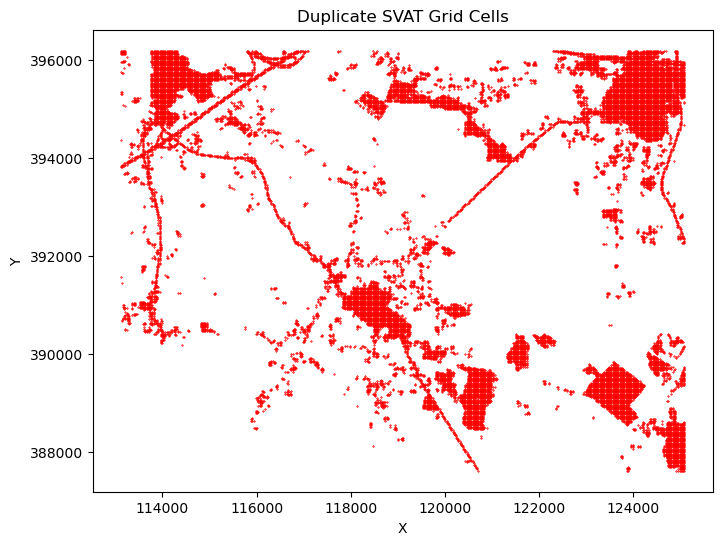

In [14]:
duplicates = DF[DF.duplicated(subset=['R', 'C'], keep=False)]
duplicates.plot.scatter(x='X', y='Y', title='Duplicate SVAT Grid Cells', figsize=(8, 6), color='red', s=0.1)

### p2

In [15]:
DF['R_C'] = DF['R'].astype(str) + '_' + DF['C'].astype(str)
DF_B['R_C'] = DF_B['R'].astype(str) + '_' + DF_B['C'].astype(str)

In [16]:
# list of NBr54 SVATs not in NBr52 (Assuming it's all cells in first/last row/column). We'll check that.
DF_inside = DF.loc[~DF['R'].isin([1, DF['R'].max()]) & ~DF['C'].isin([1, DF['C'].max()])] 
DF_inside

,SVAT unit,R,C,X,Y,R_C
481,482,2,2,113137.5,396162.5,2_2
482,483,2,3,113162.5,396162.5,2_3
483,484,2,4,113187.5,396162.5,2_4
484,485,2,5,113212.5,396162.5,2_5
485,486,2,6,113237.5,396162.5,2_6
...,...,...,...,...,...,...
185855,185856,343,475,124962.5,387637.5,343_475
185856,185857,343,476,124987.5,387637.5,343_476
185857,185858,343,477,125012.5,387637.5,343_477
185858,185859,343,478,125037.5,387637.5,343_478


In [17]:
SVATs_clean = DF_inside['SVAT unit']

In [18]:
print(f"{len(DF_inside)-len(DF_B)} SVAT grid cells in NBr54 that are not in NBr52 - {(len(DF_inside)-len(DF_B))/len(DF_inside)*100:.2f}%")

636 SVAT grid cells in NBr54 that are not in NBr52 - 0.35%


Acceptable loss. But I should make sure to remove the outer boundary cells from imod_python Sims.

## 2.1 area_svat

In [19]:
param = 'area_svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [20]:
DF.describe()

,SVAT unit,area,temperature at bottom of soil profile,soil physical unit number / or / soil physical unit descriptive string,land use type,root zone thickness / maximum
count,185871.00000,185871.000000,185871.000000,185871.000000,185871.000000,185871.000000
mean,92936.00000,555.100146,12.865228,105.847152,8.734079,0.516239
std,53656.48028,196.251930,5.270758,34.970558,7.184692,0.299014
min,1.00000,0.384169,1.083940,36.000000,1.000000,0.050000
25%,46468.50000,624.237760,8.840000,79.000000,1.000000,0.300000
50%,92936.00000,625.000000,12.352400,84.000000,11.000000,0.350000
75%,139403.50000,625.000000,16.646000,130.000000,17.000000,1.000000
max,185871.00000,625.000000,29.856300,360.000000,22.000000,1.000000


In [21]:
DF_B.describe()

,SVAT unit,area,temperature at bottom of soil profile,soil physical unit number / or / soil physical unit descriptive string,land use type,root zone thickness / maximum,meteorological region code number,local calibration factor for precipitation,local calibration factor for potential evapotranspiration of reference crop
count,183388.00000,183388.000000,183388.000000,183388.000000,183388.000000,183388.000000,183388.0,183388.0,183388.0
mean,91694.50000,536.798038,12.879104,105.777096,8.718346,0.481972,1.0,1.0,1.0
std,52939.69992,150.606197,5.252083,34.991614,7.175392,0.317850,0.0,0.0,0.0
min,1.00000,1.110000,1.084000,36.000000,1.000000,0.100000,1.0,1.0,1.0
25%,45847.75000,500.000000,8.867000,79.000000,1.000000,0.300000,1.0,1.0,1.0
50%,91694.50000,625.000000,12.360500,84.000000,11.000000,0.350000,1.0,1.0,1.0
75%,137541.25000,625.000000,16.655000,130.000000,17.000000,0.750000,1.0,1.0,1.0
max,183388.00000,625.000000,29.856000,360.000000,22.000000,1.000000,1.0,1.0,1.0


Differences in area are concering, but let's see if it's more similar for non first and last rows and Cols.

In [22]:
DF.loc[DF['SVAT unit'].isin(SVATs_clean)].describe()

,SVAT unit,area,temperature at bottom of soil profile,soil physical unit number / or / soil physical unit descriptive string,land use type,root zone thickness / maximum
count,184024.000000,184024.000000,184024.000000,184024.000000,184024.000000,184024.000000
mean,92940.664984,555.089051,12.867458,105.784756,8.750413,0.517066
std,53442.901314,196.266114,5.253305,34.970745,7.183651,0.299450
min,482.000000,0.384169,1.083940,36.000000,1.000000,0.050000
25%,46679.750000,624.237760,8.853417,79.000000,1.000000,0.300000
50%,92877.500000,625.000000,12.353600,84.000000,11.000000,0.350000
75%,139075.250000,625.000000,16.640400,130.000000,17.000000,1.000000
max,185860.000000,625.000000,29.856300,360.000000,22.000000,1.000000


Much closer now, we'll only compare the inner SVATs.

## 2.2 fact_svat

In [23]:
param = 'fact_svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

True

## 2.4 infi_svat

In [24]:
param = 'infi_svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [25]:
DF.loc[DF['SVAT unit'].isin(SVATs_clean)].describe()

,SVAT unit,infiltration capacity of soil surface,downward flow resistance of soil surface,upward flow resistance of soil surface,flow resistance of bottom flux link (c-link),extra storage coefficient of phreatic layer
count,184024.000000,184024.000000,184024.0,184024.0,184024.0,184024.0
mean,92940.664984,0.932758,9999.0,9999.0,9999.0,1.0
std,53442.901314,0.330695,0.0,0.0,0.0,0.0
min,482.000000,0.000000,9999.0,9999.0,9999.0,1.0
25%,46679.750000,1.050000,9999.0,9999.0,9999.0,1.0
50%,92877.500000,1.050000,9999.0,9999.0,9999.0,1.0
75%,139075.250000,1.050000,9999.0,9999.0,9999.0,1.0
max,185860.000000,1.050000,9999.0,9999.0,9999.0,1.0


In [26]:
DF_B.describe()

,SVAT unit,infiltration capacity of soil surface,downward flow resistance of soil surface,upward flow resistance of soil surface,flow resistance of bottom flux link (c-link),extra storage coefficient of phreatic layer
count,183388.00000,183388.000000,183388.0,183388.0,183388.0,183388.0
mean,91694.50000,0.932351,-9999.0,-9999.0,-9999.0,-9999.0
std,52939.69992,0.331196,0.0,0.0,0.0,0.0
min,1.00000,0.000000,-9999.0,-9999.0,-9999.0,-9999.0
25%,45847.75000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
50%,91694.50000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
75%,137541.25000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
max,183388.00000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0


## 2.5 init_svat

In [27]:
param = 'init_svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

True

## 2.6 luse_svat

In [28]:
param = 'luse_svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

True

## 2.7 mete_grid

In [29]:
param = 'mete_grid'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [30]:
DF.describe(include='all')

,time from 00:00:00,year number,path\name precipitation grid,path\name evapotranspiration grid(reference crop values),path\name min. day temperature grid,path\name max. day temperature grid,path\name mean temperature grid,path\name relative sunshine duration grid,path\name radiation grid,path\name humidity grid,path\name wind speed grid
count,4383.000000,4383.000000,4383,4383,4383,4383,4383,4383,4383,4383,4383
unique,NaN,NaN,4383,4383,1,1,1,1,1,1,1
top,NaN,NaN,G:\models\NBr\In\CAP\P\NBr1\P_19930101_NBr1.asc,G:\models\NBr\In\CAP\PET\NBr1\PET_19930101_NBr...,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue
freq,NaN,NaN,1,1,4383,4383,4383,4383,4383,4383,4383
mean,182.125257,1998.501027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,105.450673,3.452545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1993.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,91.000000,1996.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,182.000000,1999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,273.000000,2001.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
DF_B.describe(include='all')

,time from 00:00:00,year number,path\name precipitation grid,path\name evapotranspiration grid(reference crop values),path\name min. day temperature grid,path\name max. day temperature grid,path\name mean temperature grid,path\name relative sunshine duration grid,path\name radiation grid,path\name humidity grid,path\name wind speed grid
count,4383.000000,4383.000000,4383,4383,4383,4383,4383,4383,4383,4383,4383
unique,NaN,NaN,4383,4383,1,1,1,1,1,1,1
top,NaN,NaN,G:\models\NBr\In\CAP\P\NBr1\P_19930101_NBr1.asc,G:\models\NBr\In\CAP\PET\NBr1\PET_19930101_NBr...,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue
freq,NaN,NaN,1,1,4383,4383,4383,4383,4383,4383,4383
mean,182.125257,1998.501027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,105.450673,3.452545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1993.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,91.000000,1996.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,182.000000,1999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,273.000000,2001.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['path\name precipitation grid', 'path\name evapotranspiration grid(reference crop values)'], dtype='object')

## 2.8 mod2svat

In [33]:
param = 'mod2svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [34]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['Modflow-id', 'index of SVAT-unit', 'layer of SVAT-unit'], dtype='object')

In [35]:
DF.describe(include='all')

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
count,2.137740e+05,213774.000000,213774.000000
mean,2.849676e+05,92164.882455,2.902448
std,5.351628e+05,53664.810435,4.957190
min,1.000000e+00,1.000000,1.000000
25%,4.305025e+04,45978.250000,1.000000
50%,9.413650e+04,91874.500000,1.000000
75%,1.410248e+05,139417.000000,1.000000
max,2.174965e+06,185871.000000,19.000000


In [36]:
DF_B.describe(include='all')

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
count,2.091740e+05,209174.000000,209174.000000
mean,2.743038e+05,91809.175270,2.799927
std,5.237708e+05,53199.856967,4.845565
min,4.820000e+02,1.000000,1.000000
25%,4.299725e+04,46011.250000,1.000000
50%,9.344250e+04,91876.500000,1.000000
75%,1.395698e+05,137687.000000,1.000000
max,2.172913e+06,183388.000000,19.000000


## 2.9 para_sim

In [37]:
param = 'para_sim'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

Comments left in .xlsx

## 2.10 scap_svat

In [38]:
param = 'scap_svat'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [39]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['SVAT unit', 'maximum abstraction from groundwater mm/d',
       'maximum abstraction from surface water mm/d',
       'maximum abstraction from groundwater m3/d',
       'fraction of abstraction from surface water m3/d'],
      dtype='object')

In [40]:
DF.describe(include='all')

,SVAT unit,maximum abstraction from groundwater mm/d,maximum abstraction from surface water mm/d,maximum abstraction from groundwater m3/d,fraction of abstraction from surface water m3/d
count,26263.000000,0.0,0.0,26263.000000,26263.0
mean,81604.062598,NaN,NaN,15.621447,0.0
std,50317.650478,NaN,NaN,0.008511,0.0
min,1.000000,NaN,NaN,15.518300,0.0
25%,38468.500000,NaN,NaN,15.625000,0.0
50%,82520.000000,NaN,NaN,15.625000,0.0
75%,128335.000000,NaN,NaN,15.625000,0.0
max,165109.000000,NaN,NaN,15.625000,0.0


In [41]:
DF_B.describe(include='all')

,SVAT unit,maximum abstraction from groundwater mm/d,maximum abstraction from surface water mm/d,maximum abstraction from groundwater m3/d,fraction of abstraction from surface water m3/d
count,25786.000000,25786.0,0.0,0.0,0.0
mean,92624.736756,25.0,NaN,NaN,NaN
std,55008.758796,0.0,NaN,NaN,NaN
min,1.000000,25.0,NaN,NaN,NaN
25%,47826.250000,25.0,NaN,NaN,NaN
50%,93258.500000,25.0,NaN,NaN,NaN
75%,141819.750000,25.0,NaN,NaN,NaN
max,183378.000000,25.0,NaN,NaN,NaN


## 2.11 sel_key_svat_per

In [42]:
param = 'sel_key_svat_per'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

True

## 2.13 svat2etrefgrid

In [57]:
param = 'svat2etrefgrid'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [44]:
DF.loc[DF['SVAT unit'].isin(SVATs_clean)].describe()

,SVAT unit,row number of ETREF grid,column number of ETREF grid
count,184024.000000,184024.000000,184024.000000
mean,92940.664984,233.503760,119.721254
std,53442.901314,2.530364,3.498742
min,482.000000,229.000000,114.000000
25%,46679.750000,231.000000,117.000000
50%,92877.500000,234.000000,120.000000
75%,139075.250000,236.000000,123.000000
max,185860.000000,238.000000,126.000000


In [45]:
DF_B.describe(include='all')

,SVAT unit,row number of ETREF grid,column number of ETREF grid
count,183388.00000,183388.000000,183388.000000
mean,91694.50000,233.508937,119.725816
std,52939.69992,2.530613,3.495910
min,1.00000,229.000000,114.000000
25%,45847.75000,231.000000,117.000000
50%,91694.50000,234.000000,120.000000
75%,137541.25000,236.000000,123.000000
max,183388.00000,238.000000,126.000000


## 2.14 svat2precgrid

In [55]:
param = 'svat2precgrid'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [48]:
DF.loc[DF['SVAT unit'].isin(SVATs_clean)].describe()

,SVAT unit,row number of PREC grid,column number of PREC grid
count,184024.000000,184024.000000,184024.000000
mean,92940.664984,233.503760,119.721254
std,53442.901314,2.530364,3.498742
min,482.000000,229.000000,114.000000
25%,46679.750000,231.000000,117.000000
50%,92877.500000,234.000000,120.000000
75%,139075.250000,236.000000,123.000000
max,185860.000000,238.000000,126.000000


In [49]:
DF_B.describe(include='all')

,SVAT unit,row number of PREC grid,column number of PREC grid,weight of PREC grid cell
count,183388.00000,183388.000000,183388.000000,183388.000000
mean,91694.50000,233.508937,119.725816,233.508937
std,52939.69992,2.530613,3.495910,2.530613
min,1.00000,229.000000,114.000000,229.000000
25%,45847.75000,231.000000,117.000000,231.000000
50%,91694.50000,234.000000,120.000000,234.000000
75%,137541.25000,236.000000,123.000000,236.000000
max,183388.00000,238.000000,126.000000,238.000000


## 2.15 svat2swnr_roff

In [54]:
param = 'svat2swnr_roff'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [51]:
DF.loc[DF['SVAT unit'].isin(SVATs_clean)].describe()

,SVAT unit,surface water location identifier,"micro-storage capacity, =sill of the runoff relationship",runoff resistance,runon resistance
count,184024.000000,184024.0,1.840240e+05,184024.0,184024.0
mean,92940.664984,0.0,2.000000e-03,1.0,1.0
std,53442.901314,0.0,5.593197e-15,0.0,0.0
min,482.000000,0.0,2.000000e-03,1.0,1.0
25%,46679.750000,0.0,2.000000e-03,1.0,1.0
50%,92877.500000,0.0,2.000000e-03,1.0,1.0
75%,139075.250000,0.0,2.000000e-03,1.0,1.0
max,185860.000000,0.0,2.000000e-03,1.0,1.0


In [52]:
DF_B.describe(include='all')

,SVAT unit,surface water location identifier,"micro-storage capacity, =sill of the runoff relationship",runoff resistance,runon resistance
count,183388.00000,183388.0,1.833880e+05,183388.0,183388.0
mean,91694.50000,0.0,2.000000e-03,1.0,1.0
std,52939.69992,0.0,5.579320e-15,0.0,0.0
min,1.00000,0.0,2.000000e-03,1.0,1.0
25%,45847.75000,0.0,2.000000e-03,1.0,1.0
50%,91694.50000,0.0,2.000000e-03,1.0,1.0
75%,137541.25000,0.0,2.000000e-03,1.0,1.0
max,183388.00000,0.0,2.000000e-03,1.0,1.0


## 2.17 tiop_sim 

In [58]:
param = 'tiop_sim'
DF, DF_B = d_DF[M.MdlN][param].copy(), d_DF[MB.MdlN][param].copy()
DF.equals(DF_B)

False

In [60]:
DF.describe()

,time from beginning of year at 00:00:00,year number,option number
count,1097.000000,1097.000000,1097.0
mean,182.000912,1997.000912,7.0
std,105.606102,0.818914,0.0
min,0.000000,1996.000000,7.0
25%,91.000000,1996.000000,7.0
50%,182.000000,1997.000000,7.0
75%,273.000000,1998.000000,7.0
max,365.000000,1999.000000,7.0


In [61]:
DF_B.describe(include='all')

,time from beginning of year at 00:00:00,year number,option number
count,10227.000000,10227.000000,10227.0
mean,182.125257,2006.501027,7.0
std,105.443798,8.078184,0.0
min,0.000000,1993.000000,7.0
25%,91.000000,2000.000000,7.0
50%,182.000000,2007.000000,7.0
75%,273.000000,2013.500000,7.0
max,365.000000,2020.000000,7.0


## 2.18 uscl_svat

Missing in NBr54